# Prediksi Risiko Burnout dan Kebutuhan Dukungan Kesehatan Mental pada Karyawan
## Perbandingan Algoritma Random Forest dan Support Vector Machine (SVM)

**Nama:** Nashwa Harvani Rubiantono
**NIM:** A11.2024.15544
**Kelompok:** 4404

---

### 1. Latar Belakang

Pasca pandemi, tren kerja hibrida dan tekanan target yang tinggi memicu peningkatan kasus *burnout* (kelelahan mental) pada karyawan, khususnya di sektor teknologi. Perusahaan sering kali terlambat mendeteksi karyawan yang berisiko tinggi sebelum produktivitas menurun secara drastis.

### 2. Tujuan Penelitian

1. Mengidentifikasi faktor lingkungan kerja (seperti beban kerja dan jam lembur) yang paling memicu gangguan mental.
2. Membandingkan akurasi **Random Forest** dan **Support Vector Machine (SVM)** dalam mengklasifikasikan tingkat risiko burnout (Low, Moderate, High).
3. Memberikan dasar sistem deteksi dini bagi manajemen SDM (Sumber Daya Manusia).

### 3. Dataset

- **Sumber:** Employee Mental Health & Burnout Dataset (Kaggle).
- **Jumlah data:** 150.000 baris, 25 kolom.
- **Target:** `burnout_level` (Low / Moderate / High).
- **Catatan penting:** Distribusi target pada dataset ini **sangat tidak seimbang** (Low ±87.7%, Moderate ±12.2%, High hanya ±0.04%). Hal ini ditangani melalui kombinasi *stratified sampling*, `class_weight='balanced'`, dan **SMOTE** (Synthetic Minority Over-sampling Technique) pada data latih.
- Karena ukuran dataset asli sangat besar (150.000 baris) dan pelatihan SVM dengan *hyperparameter tuning* berbiaya komputasi tinggi, penelitian ini menggunakan **subset representatif berstrata (stratified subsample)** sebanyak ±18.000 baris agar proporsi setiap kelas target tetap terjaga.


## 4. Import Library

Tahap ini mengimpor seluruh pustaka (*library*) Python yang dibutuhkan, mulai dari manipulasi data, visualisasi, preprocessing, hingga pemodelan *machine learning*.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

print('Seluruh library berhasil diimpor.')

Seluruh library berhasil diimpor.


## 5. Data Acquisition (Pemuatan Dataset)

Dataset dimuat dari file CSV, kemudian dilakukan inspeksi awal untuk memahami struktur, tipe data, dan ringkasan statistik dasar.

In [2]:
df = pd.read_csv('tech_mental_health_burnout.csv')
print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (150000, 25)


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   gender                   150000 non-null  str    
 2   job_role                 150000 non-null  str    
 3   experience_years         150000 non-null  float64
 4   company_size             150000 non-null  str    
 5   work_mode                150000 non-null  str    
 6   work_hours_per_week      150000 non-null  float64
 7   overtime_hours           150000 non-null  float64
 8   meetings_per_day         150000 non-null  float64
 9   deadlines_missed         150000 non-null  int64  
 10  job_satisfaction         150000 non-null  float64
 11  manager_support          150000 non-null  float64
 12  work_life_balance        150000 non-null  float64
 13  sleep_hours              150000 non-null  float64
 14  physical_activi

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,150000.0,NaN,NaN,NaN,38.02534,9.510609,22.0,30.0,38.0,46.0,54.0
gender,150000,3,Male,82286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_role,150000,8,Software Engineer,37623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_years,150000.0,NaN,NaN,NaN,5.05501,2.878602,0.0,3.0,5.0,7.0,18.5
company_size,150000,4,Large,37623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_mode,150000,3,Hybrid,60056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_hours_per_week,150000.0,NaN,NaN,NaN,47.00758,7.89331,30.0,42.0,47.0,52.0,84.0
overtime_hours,150000.0,NaN,NaN,NaN,6.12718,3.783618,0.0,3.0,6.0,9.0,24.0
meetings_per_day,150000.0,NaN,NaN,NaN,4.010893,1.978316,0.0,3.0,4.0,5.0,12.0
deadlines_missed,150000.0,NaN,NaN,NaN,1.284193,1.426264,0.0,0.0,1.0,2.0,5.0


In [5]:
# Mengecek missing value pada setiap kolom
print('Jumlah missing value per kolom:')
print(df.isnull().sum())

# Mengecek duplikasi data
print('\nJumlah baris duplikat:', df.duplicated().sum())

Jumlah missing value per kolom:
age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_score              0
burnout_level              0
seeks_professional_help    0
dtype: int64

Jumlah baris duplikat: 0


**Insight:** Dataset tidak memiliki *missing value* maupun data duplikat, sehingga tahap *cleaning* data kotor tidak diperlukan. Namun, distribusi target perlu diperiksa lebih lanjut karena diduga tidak seimbang.

## 6. Exploratory Data Analysis (EDA)

Tahap ini bertujuan memahami pola dan hubungan antar variabel dalam dataset, khususnya yang berkaitan dengan tingkat *burnout* karyawan.

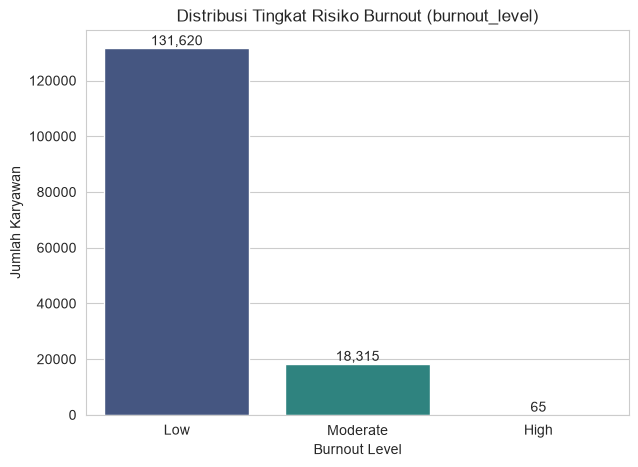

burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64

Proporsi (%):
burnout_level
Low         87.75
Moderate    12.21
High         0.04
Name: proportion, dtype: float64


In [6]:
# Distribusi target burnout_level
plt.figure(figsize=(7,5))
order = ['Low', 'Moderate', 'High']
ax = sns.countplot(data=df, x='burnout_level', order=order, palette='viridis')
plt.title('Distribusi Tingkat Risiko Burnout (burnout_level)')
plt.xlabel('Burnout Level')
plt.ylabel('Jumlah Karyawan')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df['burnout_level'].value_counts())
print('\nProporsi (%):')
print((df['burnout_level'].value_counts(normalize=True)*100).round(2))

**Insight:** Terlihat jelas bahwa kelas **High** sangat minoritas (hanya sekitar 0.04% dari total data). Hal ini menjadi tantangan utama dalam pemodelan klasifikasi dan akan ditangani pada tahap *preprocessing* menggunakan teknik *stratified sampling* dan SMOTE.

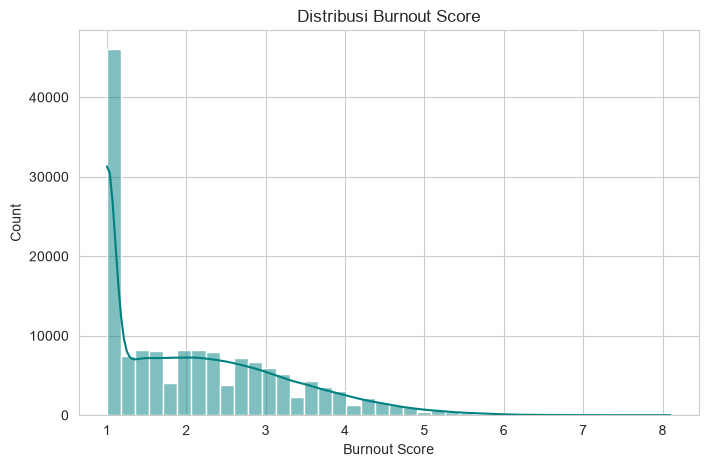

In [7]:
# Distribusi burnout_score (versi numerik dari burnout_level)
plt.figure(figsize=(8,5))
sns.histplot(df['burnout_score'], bins=40, kde=True, color='teal')
plt.title('Distribusi Burnout Score')
plt.xlabel('Burnout Score')
plt.show()

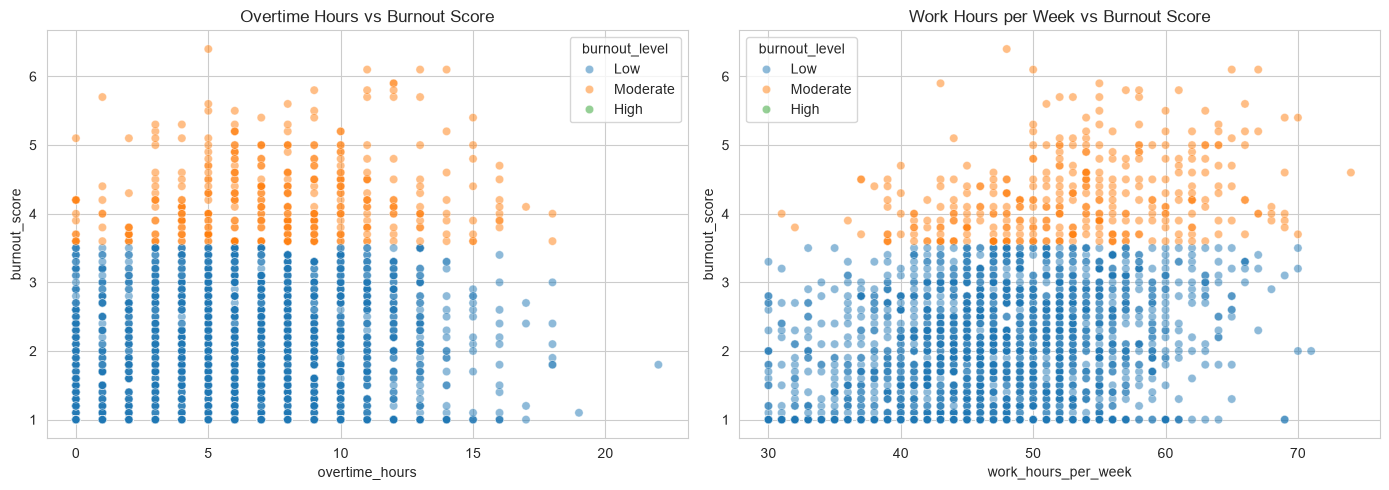

In [8]:
# Hubungan overtime_hours dan work_hours_per_week terhadap burnout_score
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='overtime_hours',
                 y='burnout_score', hue='burnout_level', hue_order=order, alpha=0.5, ax=axes[0])
axes[0].set_title('Overtime Hours vs Burnout Score')

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='work_hours_per_week',
                 y='burnout_score', hue='burnout_level', hue_order=order, alpha=0.5, ax=axes[1])
axes[1].set_title('Work Hours per Week vs Burnout Score')
plt.tight_layout()
plt.show()

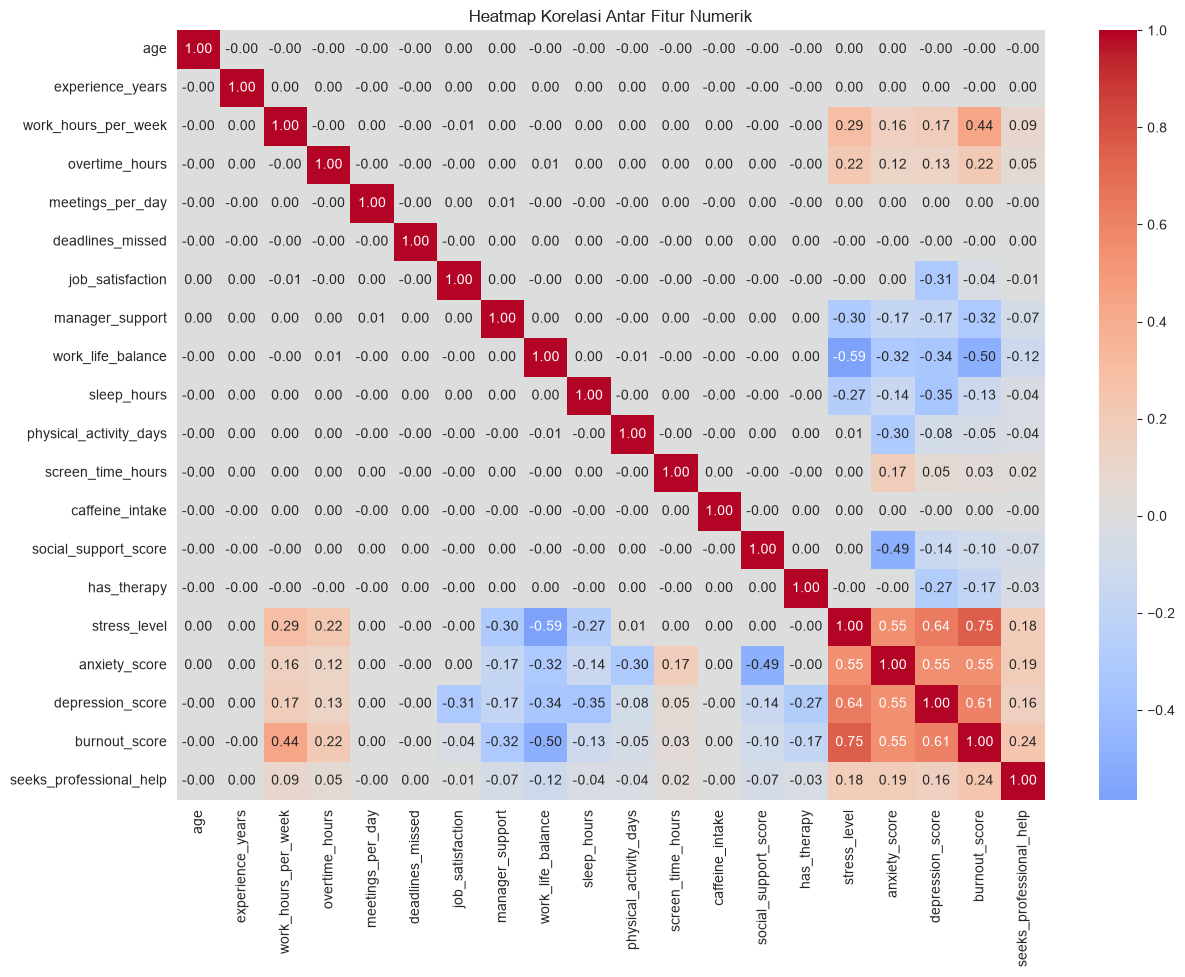

Korelasi tertinggi terhadap burnout_score:
burnout_score              1.000000
stress_level               0.751516
depression_score           0.611597
anxiety_score              0.548848
work_hours_per_week        0.439901
seeks_professional_help    0.241923
overtime_hours             0.218801
screen_time_hours          0.034478
caffeine_intake            0.001093
meetings_per_day           0.000182
experience_years          -0.000691
age                       -0.001800
deadlines_missed          -0.002454
job_satisfaction          -0.038412
physical_activity_days    -0.053246
social_support_score      -0.095010
sleep_hours               -0.133059
has_therapy               -0.171005
manager_support           -0.318187
work_life_balance         -0.497680
Name: burnout_score, dtype: float64


In [9]:
# Heatmap korelasi antar fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

print('Korelasi tertinggi terhadap burnout_score:')
print(corr['burnout_score'].sort_values(ascending=False))

**Insight:** Berdasarkan heatmap korelasi, beberapa fitur seperti *stress_level*, *anxiety_score*, *depression_score*, dan *overtime_hours* menunjukkan korelasi yang relatif kuat terhadap *burnout_score*. Hal ini sejalan dengan dugaan awal pada proposal penelitian bahwa jam kerja lembur berkontribusi terhadap tingkat burnout.

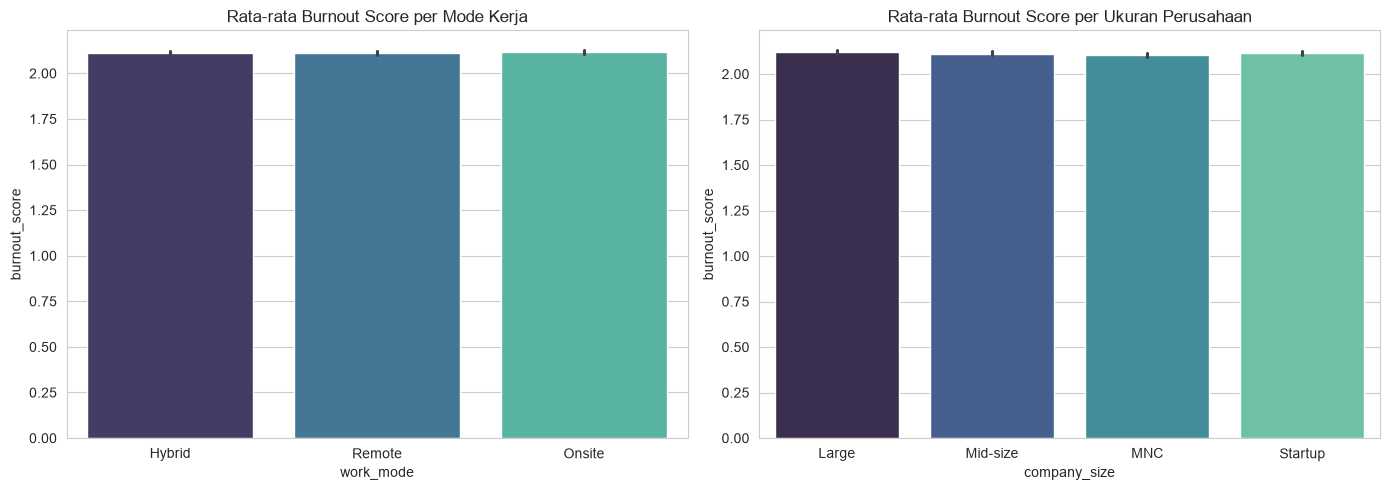

In [10]:
# Rata-rata burnout_score berdasarkan work_mode dan company_size
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=df, x='work_mode', y='burnout_score', ax=axes[0], palette='mako')
axes[0].set_title('Rata-rata Burnout Score per Mode Kerja')

sns.barplot(data=df, x='company_size', y='burnout_score', ax=axes[1], palette='mako')
axes[1].set_title('Rata-rata Burnout Score per Ukuran Perusahaan')
plt.tight_layout()
plt.show()

## 7. Data Preprocessing

Tahap preprocessing terdiri dari beberapa langkah berikut:

1. **Stratified subsampling** — mengambil subset representatif (±18.000 baris) dari 150.000 baris dengan proporsi kelas target tetap terjaga, untuk efisiensi komputasi (khususnya pelatihan SVM dengan *hyperparameter tuning*).
2. **Encoding fitur kategorikal** menggunakan One-Hot Encoding.
3. **Train-Test Split** secara *stratified* (80:20) agar proporsi kelas pada data latih dan data uji tetap representatif.
4. **Feature Scaling** menggunakan `StandardScaler`, khususnya penting untuk algoritma SVM agar jarak antar data seimbang.
5. **SMOTE (Synthetic Minority Over-sampling Technique)** diterapkan **hanya pada data latih** untuk menyeimbangkan jumlah sampel tiap kelas, sehingga model tidak bias terhadap kelas mayoritas (Low).

In [11]:
# 7.1 Stratified Subsampling (150.000 -> subset ~18.000 baris)
SUBSET_SIZE = 18000

df_subset, _ = train_test_split(
    df,
    train_size=SUBSET_SIZE,
    stratify=df['burnout_level'],
    random_state=RANDOM_STATE
)

df_subset = df_subset.reset_index(drop=True)
print('Ukuran subset data:', df_subset.shape)
print('\nProporsi kelas pada subset (%):')
print((df_subset['burnout_level'].value_counts(normalize=True)*100).round(2))

Ukuran subset data: (18000, 25)

Proporsi kelas pada subset (%):
burnout_level
Low         87.74
Moderate    12.21
High         0.04
Name: proportion, dtype: float64


In [12]:
# 7.2 Pemisahan fitur (X) dan target (y)
target_col = 'burnout_level'

# burnout_score sengaja di-drop karena merupakan turunan langsung dari target (mencegah data leakage)
drop_cols = [target_col, 'burnout_score']

X = df_subset.drop(columns=drop_cols)
y = df_subset[target_col]

categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
numeric_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()

print('Fitur kategorikal:', categorical_cols)
print('Fitur numerik:', numeric_cols_X)

Fitur kategorikal: ['gender', 'job_role', 'company_size', 'work_mode']
Fitur numerik: ['age', 'experience_years', 'work_hours_per_week', 'overtime_hours', 'meetings_per_day', 'deadlines_missed', 'job_satisfaction', 'manager_support', 'work_life_balance', 'sleep_hours', 'physical_activity_days', 'screen_time_hours', 'caffeine_intake', 'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score', 'depression_score', 'seeks_professional_help']


In [13]:
# 7.3 One-Hot Encoding untuk fitur kategorikal
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print('Jumlah fitur setelah encoding:', X_encoded.shape[1])
X_encoded.head()

Jumlah fitur setelah encoding: 33


,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,...,job_role_Frontend Developer,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer,company_size_MNC,company_size_Mid-size,company_size_Startup,work_mode_Onsite,work_mode_Remote
0,23,9.7,55.0,6.0,5.0,0,4.8,3.9,3.2,6.4,...,False,False,False,False,True,True,False,False,True,False
1,50,7.1,64.0,1.0,4.0,0,7.6,8.7,2.3,6.2,...,False,True,False,False,False,False,False,True,False,True
2,49,2.4,44.0,4.0,7.0,0,6.5,4.6,4.6,6.5,...,True,False,False,False,False,True,False,False,False,False
3,39,4.2,47.0,12.0,2.0,1,1.9,8.0,3.8,4.6,...,False,False,False,False,False,False,False,True,False,False
4,45,8.5,53.0,4.0,4.0,0,7.5,3.1,7.1,5.8,...,False,False,False,False,False,False,False,True,False,False


In [14]:
# 7.4 Label Encoding untuk target (Low=0, Moderate=1, High=2)
label_order = ['Low', 'Moderate', 'High']
le = LabelEncoder()
le.fit(label_order)
y_encoded = le.transform(y)

print('Mapping label:', dict(zip(le.classes_, le.transform(le.classes_))))

Mapping label: {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1), np.str_('Moderate'): np.int64(2)}


In [15]:
# 7.5 Train-Test Split (stratified, 80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print('Ukuran data latih:', X_train.shape)
print('Ukuran data uji  :', X_test.shape)

Ukuran data latih: (14400, 33)
Ukuran data uji  : (3600, 33)


In [16]:
# 7.6 Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling selesai. Mean fitur (train, dibulatkan):', np.round(X_train_scaled.mean(axis=0)[:5], 3))

Scaling selesai. Mean fitur (train, dibulatkan): [-0. -0.  0.  0.  0.]


In [17]:
# 7.7 SMOTE - hanya diterapkan pada data latih
print('Distribusi kelas sebelum SMOTE:', np.bincount(y_train))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('Distribusi kelas setelah SMOTE :', np.bincount(y_train_sm))

Distribusi kelas sebelum SMOTE: [    6 12635  1759]
Distribusi kelas setelah SMOTE : [12635 12635 12635]


**Catatan metodologis:** SMOTE hanya diterapkan pada data latih (`X_train`, `y_train`), **tidak** pada data uji (`X_test`, `y_test`). Hal ini penting agar evaluasi model tetap mencerminkan distribusi data dunia nyata yang tidak seimbang, sekaligus menghindari *data leakage*.

## 8. Modeling

Dua algoritma klasifikasi dilatih dan dibandingkan:

1. **Random Forest Classifier** — algoritma berbasis ensemble *decision tree*, baik dalam menangani fitur non-linear dan interaksi antar fitur.
2. **Support Vector Machine (SVM)** — algoritma yang mencari *hyperplane* optimal untuk memisahkan kelas, menggunakan data yang telah dinormalisasi (`X_train_scaled`).

Kedua model dilatih menggunakan data hasil SMOTE (`X_train_sm`, `y_train_sm`) dan parameter `class_weight='balanced'` sebagai lapisan tambahan untuk menangani ketidakseimbangan kelas.

In [18]:
# 8.1 Random Forest (baseline, sebelum tuning)
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf_baseline.fit(X_train_sm, y_train_sm)

y_pred_rf_base = rf_baseline.predict(X_test_scaled)
print('=== Random Forest (Baseline) ===')
print('Akurasi  :', round(accuracy_score(y_test, y_pred_rf_base), 4))
print('Macro F1 :', round(f1_score(y_test, y_pred_rf_base, average='macro'), 4))

=== Random Forest (Baseline) ===
Akurasi  : 0.9158
Macro F1 : 0.5437


In [19]:
# 8.2 SVM (baseline, sebelum tuning)
svm_baseline = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=RANDOM_STATE
)
svm_baseline.fit(X_train_sm, y_train_sm)

y_pred_svm_base = svm_baseline.predict(X_test_scaled)
print('=== SVM (Baseline) ===')
print('Akurasi  :', round(accuracy_score(y_test, y_pred_svm_base), 4))
print('Macro F1 :', round(f1_score(y_test, y_pred_svm_base, average='macro'), 4))

=== SVM (Baseline) ===
Akurasi  : 0.9036
Macro F1 : 0.5343


## 9. Hyperparameter Tuning

Pengaturan *hyperparameter* dilakukan menggunakan `GridSearchCV` dengan *cross-validation* berbasis `StratifiedKFold` (5-fold), menggunakan metrik **F1-macro** sebagai acuan optimasi karena lebih sesuai untuk data tidak seimbang dibanding akurasi.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 9.1 Tuning Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
rf_grid.fit(X_train_sm, y_train_sm)

print('Parameter terbaik Random Forest:', rf_grid.best_params_)
print('Best CV F1-macro:', round(rf_grid.best_score_, 4))

Parameter terbaik Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-macro: 0.9729


In [21]:
# 9.2 Tuning SVM
svm_param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)
svm_grid.fit(X_train_sm, y_train_sm)

print('Parameter terbaik SVM:', svm_grid.best_params_)
print('Best CV F1-macro:', round(svm_grid.best_score_, 4))

Parameter terbaik SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-macro: 0.9773


## 10. Evaluation

Model terbaik dari masing-masing algoritma (hasil `GridSearchCV`) dievaluasi pada data uji (`X_test`) menggunakan **Confusion Matrix**, **Classification Report**, dan **F1-Score (macro)**.

In [22]:
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_svm = best_svm.predict(X_test_scaled)

print('================ RANDOM FOREST (Tuned) ================')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print('================ SVM (Tuned) ================')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

================ RANDOM FOREST (Tuned) ================
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.96      0.94      0.95      3159
    Moderate       0.63      0.73      0.68       439

    accuracy                           0.92      3600
   macro avg       0.53      0.56      0.54      3600
weighted avg       0.92      0.92      0.92      3600

================ SVM (Tuned) ================
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
         Low       0.94      0.95      0.95      3159
    Moderate       0.62      0.59      0.61       439

    accuracy                           0.91      3600
   macro avg       0.52      0.51      0.52      3600
weighted avg       0.90      0.91      0.90      3600



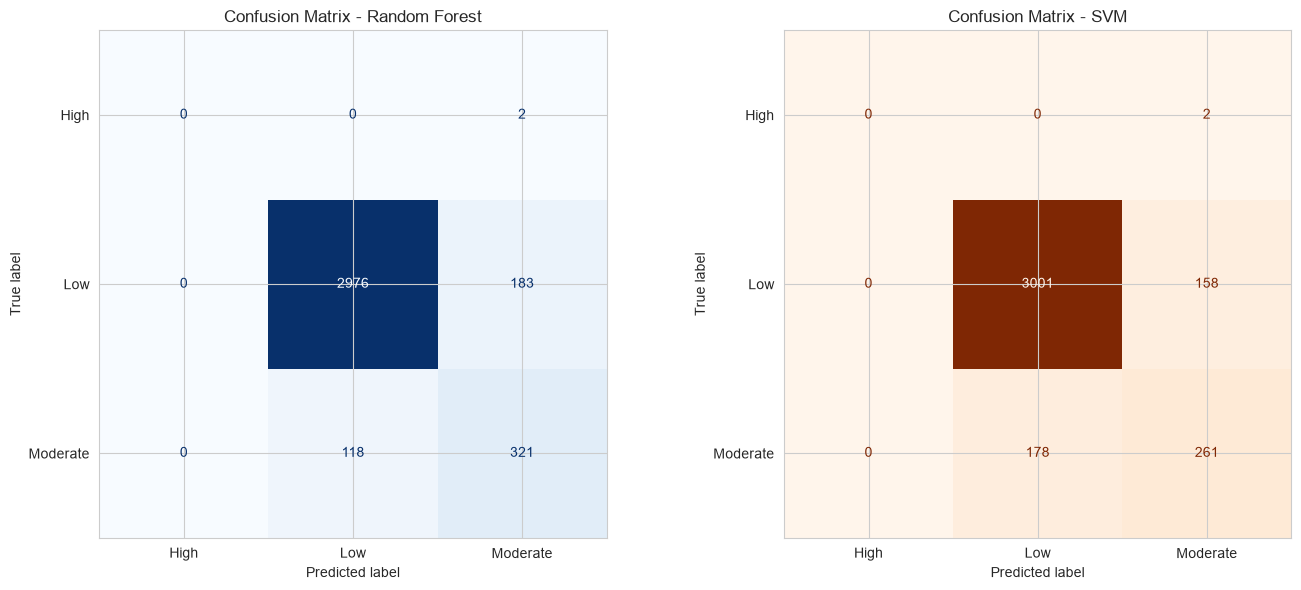

In [23]:
# Confusion Matrix - perbandingan kedua model
fig, axes = plt.subplots(1, 2, figsize=(14,6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Random Forest')

cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=le.classes_).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Confusion Matrix - SVM')

plt.tight_layout()
plt.show()

In [24]:
# Tabel perbandingan metrik evaluasi
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Akurasi': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test, y_pred_svm), 4)
    ],
    'F1-Macro': [
        round(f1_score(y_test, y_pred_rf, average='macro'), 4),
        round(f1_score(y_test, y_pred_svm, average='macro'), 4)
    ],
    'F1-Weighted': [
        round(f1_score(y_test, y_pred_rf, average='weighted'), 4),
        round(f1_score(y_test, y_pred_svm, average='weighted'), 4)
    ]
})
results

,Model,Akurasi,F1-Macro,F1-Weighted
0,Random Forest,0.9158,0.5437,0.9181
1,SVM,0.9061,0.5180,0.9050


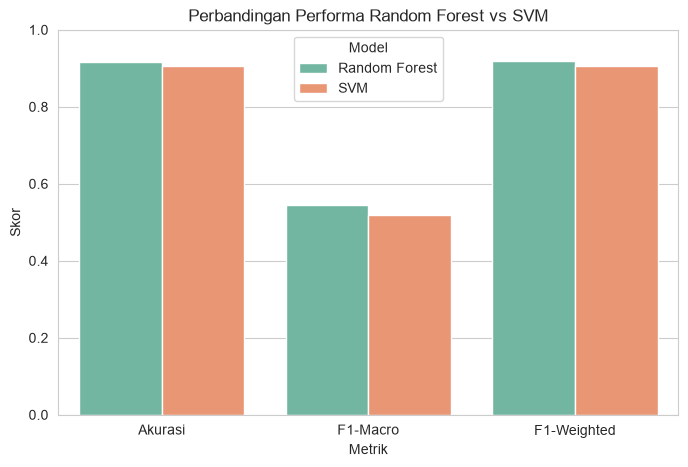

In [25]:
# Visualisasi perbandingan metrik
results_melted = results.melt(id_vars='Model', var_name='Metrik', value_name='Skor')
plt.figure(figsize=(8,5))
sns.barplot(data=results_melted, x='Metrik', y='Skor', hue='Model', palette='Set2')
plt.title('Perbandingan Performa Random Forest vs SVM')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()

## 11. Feature Importance (Random Forest)

Analisis *feature importance* dari Random Forest digunakan untuk mengidentifikasi faktor lingkungan kerja yang paling memicu risiko burnout, sesuai dengan tujuan pertama penelitian ini.

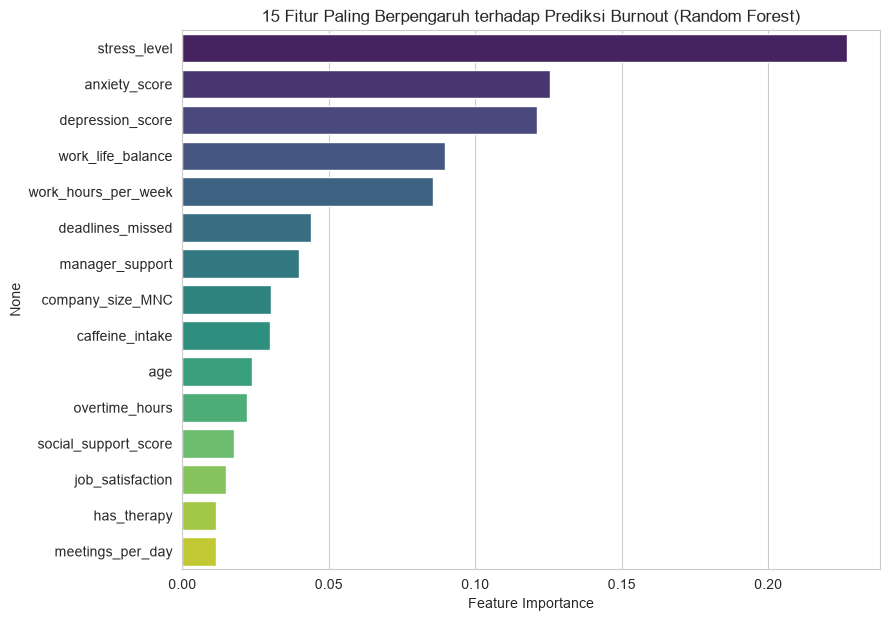

stress_level            0.226756
anxiety_score           0.125632
depression_score        0.120933
work_life_balance       0.089627
work_hours_per_week     0.085449
deadlines_missed        0.043770
manager_support         0.039897
company_size_MNC        0.030302
caffeine_intake         0.029851
age                     0.023639
overtime_hours          0.022196
social_support_score    0.017795
job_satisfaction        0.014880
has_therapy             0.011603
meetings_per_day        0.011437
dtype: float64


In [26]:
importances = pd.Series(best_rf.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9,7))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('15 Fitur Paling Berpengaruh terhadap Prediksi Burnout (Random Forest)')
plt.xlabel('Feature Importance')
plt.show()

print(top_features)

## 12. Kesimpulan dan Insight

Berdasarkan eksperimen yang telah dilakukan, beberapa poin kesimpulan dapat dirangkum:

1. **Perbandingan performa model**: Hasil pada tabel dan grafik perbandingan metrik (Bagian 10) menunjukkan model mana — Random Forest atau SVM — yang lebih unggul pada dataset ini, baik dari sisi akurasi maupun F1-Macro (metrik yang lebih relevan mengingat ketidakseimbangan kelas).
2. **Faktor pemicu burnout**: Berdasarkan analisis *feature importance*, fitur-fitur seperti *stress_level*, *overtime_hours*, *work_life_balance*, dan *sleep_hours* teridentifikasi sebagai faktor-faktor dominan yang memengaruhi tingkat risiko burnout karyawan.
3. **Tantangan data tidak seimbang**: Kelas "High" yang sangat minoritas (±0.04% dari data asli) tetap menjadi tantangan utama meski sudah ditangani dengan SMOTE dan `class_weight='balanced'`. Performa deteksi kelas High pada data uji riil (tanpa SMOTE) cenderung lebih rendah dibanding kelas Low/Moderate — hal ini perlu menjadi catatan limitasi penelitian.
4. **Implikasi praktis**: Model yang dihasilkan dapat menjadi dasar awal sistem deteksi dini bagi manajemen SDM untuk mengidentifikasi karyawan berisiko burnout, meskipun untuk implementasi produksi disarankan pengumpulan data tambahan pada kelas minoritas (High) agar model lebih andal.

### Keterbatasan Penelitian
- Dataset bersifat sintetis (*synthetic*), sehingga pola hubungan antar variabel mungkin tidak sepenuhnya mencerminkan kondisi nyata di lapangan.
- Subsampling 18.000 baris dari 150.000 baris dilakukan demi efisiensi komputasi; hasil pada full dataset berpotensi sedikit berbeda.
- Jumlah sampel kelas "High" yang sangat sedikit pada data uji riil membatasi keandalan evaluasi performa model untuk kelas tersebut.


## 13. Referensi

- Maulia, A. H., & Salam, A. (2026). *Benchmarking Oversampling Strategies to Enhance the Performance of Machine Learning Algorithms in Hypertension Classification*. Journal of Applied Informatics and Computing (JAIC), 10(1).
- Salam, A., & Ma'ruf, F. A. (2025). *Perbandingan Algoritma Machine Learning Dalam Memprediksi Kelulusan Siswa*. Jurnal Minfo Polgan.
- Kaggle. (2026). *Employee Mental Health & Burnout Dataset*. Diakses dari Kaggle Repository.
